In [4]:
%pip install scikit-learn
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load Titanic dataset
df = pd.read_csv(r'C:\Users\aksha\OneDrive\Documents\python_exercises\data science\titanic.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Step 1: Drop columns not useful for prediction
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Step 2: Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Step 3: Encode categorical columns to numbers
# Sex: male=1, female=0
# Embarked: S=2, Q=1, C=0
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

print("Missing values after preprocessing:")
print(df.isnull().sum())
print("\nDataFrame after preprocessing:")
df.head()

Missing values after preprocessing:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

DataFrame after preprocessing:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [6]:
# X = input features (what we use to predict)
# y = target (what we want to predict - Survived)
X = df.drop(columns=['Survived'])
y = df['Survived']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (891, 7)
Target shape: (891,)

Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [7]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (712, 7)
Testing set size: (179, 7)


In [8]:
# Scale features so all values are in same range
# Logistic regression works better with scaled data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


In [9]:
# Create and train Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
# Predict on test data
y_pred = model.predict(X_test)

print("First 10 actual values:   ", list(y_test[:10]))
print("First 10 predicted values:", list(y_pred[:10]))

First 10 actual values:    [1, 0, 0, 1, 1, 1, 1, 0, 1, 1]
First 10 predicted values: [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


In [11]:
# Calculate accuracy - how many predictions were correct
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 80.45 %


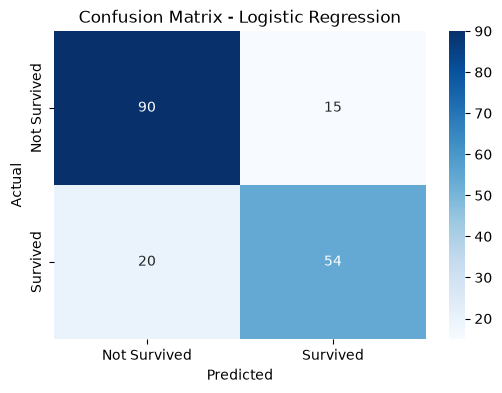

In [12]:
# Confusion matrix shows correct and wrong predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Explanation:
# Top-left: Correctly predicted Not Survived (True Negative)
# Top-right: Wrongly predicted Survived (False Positive)
# Bottom-left: Wrongly predicted Not Survived (False Negative)
# Bottom-right: Correctly predicted Survived (True Positive)

In [13]:
# Full report with precision, recall and f1-score
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Survived', 'Survived']))

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.86      0.84       105
    Survived       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



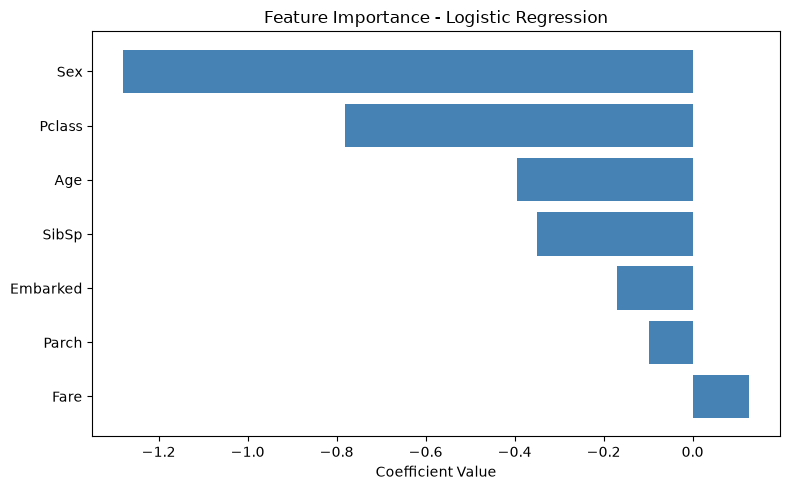

    Feature  Coefficient
5      Fare     0.126216
4     Parch    -0.098292
6  Embarked    -0.170860
3     SibSp    -0.349582
2       Age    -0.395574
0    Pclass    -0.782061
1       Sex    -1.278865


In [14]:
# Which features helped most in prediction
feature_names = df.drop(columns=['Survived']).columns
coefficients = model.coef_[0]

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_df['Feature'], feature_df['Coefficient'],
         color='steelblue')
plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print(feature_df)